In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from multiprocessing import Pool
import time
import torch
from scipy.ndimage import gaussian_filter
from ds_utils import  *
from ps_utils import  *

In [4]:
DATA_DIR = Path("/pscratch/sd/k/kp22/deft/")

NameError: name 'Path' is not defined

# Flat sky

In [ ]:
RES = 256
STEP_SIZE = 6. 
ANG_X = 6. 
ANG_Y = 6. 
flatskymapparams = [RES, RES, 60.*ANG_X/RES, 60.*ANG_X/RES] #Needs pixelres to be in arcmin
nx,ny,dx,dy = flatskymapparams
dx_rad = np.radians(dx/60.)
dy_rad = np.radians(dy/60.)
lx, ly = get_lxly(flatskymapparams)
ell_grid = np.sqrt(lx**2 + ly**2)
ptsrc=2

In [ ]:
n_samples = 801

In [ ]:
which_fg_model = 'agora'

fname = 'ilc_weights_residuals_%s_fg_model.npy' %(which_fg_model)
ilc_dict = np.load(fname, allow_pickle = True).item()
print(ilc_dict.keys())

#total ILC residuals
total_ilc_residuals_dict = ilc_dict['total_ilc_residuals']
print(total_ilc_residuals_dict.keys())

In [ ]:
ell, nl_s4_wide = total_ilc_residuals_dict['s4_wide']['mv']
ell, nl_s4_deep = total_ilc_residuals_dict['s4_deep']['mv']
ell, nl_spt3g = total_ilc_residuals_dict['spt3g']['mv']

In [ ]:
def bandpass_filter(map_i, l_c, delta_l):
    """ Filter the map in Fourier space to only include a band around l_c with width delta_l """
    fft_map = fft2(map_i)
    mask = (ell_grid >= (l_c - delta_l/2)) & (ell_grid <= (l_c + delta_l/2))
    fft_map *= mask
    return ifft2(fft_map).real

In [ ]:
def compute_cross_statistics(a, b):
    """Compute auto and cross statistics between maps a and b"""

    a_centered = a - np.mean(a)
    b_centered = b - np.mean(b)

    S2aa = np.mean(a_centered**2)
    S2bb = np.mean(b_centered**2)
    S2ab = np.mean(a_centered * b_centered)

    S3aaa = np.mean(a_centered**3)
    S3bbb = np.mean(b_centered**3)
    S3aab = np.mean(a_centered**2 * b_centered)
    S3abb = np.mean(a_centered * b_centered**2)

    S4aaaa = np.mean(a_centered**4) - 3 * S2aa**2
    S4bbbb = np.mean(b_centered**4) - 3 * S2bb**2
    S4aaab = np.mean(a_centered**3 * b_centered) - 3 * S2aa * S2ab
    S4aabb = np.mean(a_centered**2 * b_centered**2) - S2aa * S2bb - 2 * S2ab**2
    S4abbb = np.mean(a_centered * b_centered**3) - 3 * S2bb * S2ab

    return [
        S2aa, S2bb, S2ab,
        S3aaa, S3bbb, S3aab, S3abb,
        S4aaaa, S4bbbb, S4aaab, S4aabb, S4abbb
    ]

In [ ]:
def compute_cross_statistics_per_band(maps, band_centers, delta_l):
    moments_data = np.empty((len(maps), len(band_centers), 12))
    for i in range(len(maps)): 
        if i % 200 == 0:
            print(f"{i}/{len(maps)}")
        noise_map = cl2map(flatskymapparams, nl_s4_deep,ell)
        map_a = maps[i, :,:, 0] 
        map_b = maps[i][:, :, 1] if maps[i].shape[2] > 1 else maps[i][:, :, 0] 

        _, apodised_tsz_mask = get_peak_masks(map_b, mask_threshold_sigma_units = mask_threshold_sigma_units_tsz, mask_radius_pixel_units = mask_radius_pixel_units, taper_radius_fac = apod_taper_radius_fac)

        map_a_masked = np.copy(map_a)#+ noise_map#*apodised_tsz_mask
        map_b_masked = np.copy(map_b)#+ noise_map #*apodised_tsz_mask
        
        for j, center in enumerate(band_centers):            
            filtered_a = bandpass_filter(map_a_masked, center, delta_l)
            filtered_b = bandpass_filter(map_b_masked, center, delta_l)
            stats = compute_cross_statistics(filtered_a, filtered_b)
            moments_data[i, j, :] = stats
            
    return moments_data

In [10]:
lmin = 300
lmax = 6000
delta_l = 720
bandpass_edges = np.arange(lmin, lmax, delta_l)
bandpass_centers = (bandpass_edges[:-1] + bandpass_edges[1:]) // 2

In [11]:
mask_threshold_sigma_units_tsz = 10.
mask_radius_pixel_units = 4
apod_taper_radius_fac = 2

In [6]:
RES = 256
STEP_SIZE = 6. * u.deg
ANG_X = 6. * u.deg
ANG_Y = 6. * u.deg
flatskymapparams = [RES, RES, 60.*ANG_X.value/RES, 60.*ANG_Y.value/RES] #Code requires pixelres to be in arcmin

In [15]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz3.npy"

cib_maps = np.load(fpath_cib)  
tsz_maps = np.load(fpath_tsz)  

agora_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
num_samples = len(agora_maps)

In [18]:
num_train = int(0.8 * num_samples)
rng = np.random.default_rng(seed=42)
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]
test_indices = indices[num_train:]
training_images = agora_maps[train_indices]
testing_images = agora_maps[test_indices]

In [253]:
train_sum_maps =  np.sum(training_images[:n_samples], axis=-1, keepdims=True)

In [190]:
moments_data_train = compute_cross_statistics_per_band(training_images[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [284]:
moments_data_train_sum = compute_cross_statistics_per_band(train_sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [191]:
np.save("data/low_pass/2mJy/moments_train_2mJy_deltaell_720_200rlz_6x6_lp_joint3_s4deep_noise.npy",moments_data_train)

In [256]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_cib_joint3.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_tsz_joint3.npy"

cib_maps = np.load(fpath_cib)  
tsz_maps = np.load(fpath_tsz)  

gaussian_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)

In [258]:
gaussian_sum_maps =  np.sum(gaussian_maps[:n_samples], axis=-1, keepdims=True)

In [286]:
moments_data_gaussian_sum = compute_cross_statistics_per_band(gaussian_sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [259]:
moments_data_gaussian = compute_cross_statistics_per_band(gaussian_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [195]:
np.save("data/low_pass/2mJy/moments_gaussian_2mJy_deltaell_720_200rlz_6x6_lp_joint3_spt3g_noise.npy",moments_data_gaussian)

In [20]:
all_samples = np.load("data/low_pass/2mJy/new_samples_16_cib_tsz3_2mJy_zero_norm_6x6_w_au_lp.npy")

In [21]:
all_samples[:,0,] *= 110.732285
all_samples[:,0,] = ((all_samples[:,0,] - np.mean(all_samples[:,0,]))*(np.std(agora_maps[:,:,:,0])/np.std(all_samples[:,0,]))) + np.mean(all_samples[:,0,])

In [22]:
all_samples[:,1,] *= 158.31772
all_samples[:,1,] -= 158.31772
all_samples[:,1,] = ((all_samples[:,1,] - np.mean(all_samples[:,1,]))*(np.std(agora_maps[:,:,:,1])/np.std(all_samples[:,1,]))) + np.mean(all_samples[:,1,])

In [23]:
all_samples = all_samples.transpose(0, 2, 3, 1)

In [24]:
all_samples_sum_maps =  np.sum(all_samples[:n_samples], axis=-1, keepdims=True)

In [200]:
moments_samples = compute_cross_statistics_per_band(all_samples[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [288]:
moments_samples_sum = compute_cross_statistics_per_band(all_samples_sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [201]:
np.save("data/low_pass/2mJy/moments_samples_curve_2mJy_deltaell_720_200rlz_6x6_lp_joint3_spt3g_noise.npy",moments_samples)

In [12]:
def load_all_moments(filename, bandpass_centers, max_lines=-1):
    moments_data = np.load(filename)[:max_lines]
    moments = {}

    norms = [
        bandpass_centers,        # S2aa
        bandpass_centers,        # S2bb
        bandpass_centers,        # S2ab
        bandpass_centers,        # S3aaa
        bandpass_centers,        # S3bbb
        bandpass_centers,        # S3aab
        bandpass_centers,        # S3abb
        bandpass_centers**2,     # S4aaaa
        bandpass_centers**2,     # S4bbbb
        bandpass_centers**2,     # S4aaab
        bandpass_centers**2,     # S4aabb
        bandpass_centers**2      # S4abbb
    ]

    for i in range(12):
        label = f"moment_{i:02d}"
        moments[label] = [m / norms[i] for m in moments_data[:, :, i]]

    return moments

In [28]:
labels = [r"$S_3$", r"$S_4$"]
moment_keys = ["moment_03", "moment_07"]

noise_levels = ["s4deep_noise"]

models = ["train", "diffusion", "gaussian"]
markers = {"train": ".", "diffusion": ".", "gaussian": "."}

noise_colors = {
    #"spt3g_noise": "goldenrod",
    #"s4wide_noise": "steelblue",
    "s4deep_noise": "mediumvioletred"
}

colors = {
    "gaussian": "orangered",
    "train": "black",
    "diffusion": "steelblue"
}

In [29]:
def load_moment_sum(model, noise=None):
    tag = "samples_curve" if model == "diffusion" else model
    suffix = f"_sum_{noise}" if noise else "_sum"
    fname = f"data/low_pass/2mJy/moments_{tag}_2mJy_deltaell_720_200rlz_6x6_lp_joint3{suffix}.npy"
    return load_all_moments(fname, bandpass_centers)

sum_data_clean = {
    model: load_moment_sum(model)
    for model in models
}

sum_data_noisy = {
    noise: {
        model: load_moment_sum(model, noise)
        for model in models
    }
    for noise in noise_levels
}

<Figure size 640x480 with 0 Axes>

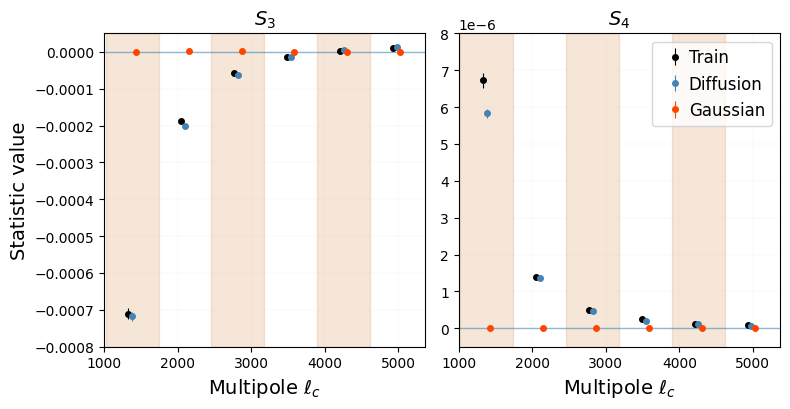

In [30]:
from pylab import *
clf()

tr, tc = 1, 2
figure(figsize=(8., 4.2))
subplots_adjust(wspace=0.1)

alphaval = 1.
mewval = 0.8
fsval = 14
msval = 8.
capsizeval = 0.

offset_step = 0.
model_offset_step = 50
bpwidth = np.diff(bandpass_centers)[0]

for idx, (label, moment_key) in enumerate(zip(labels, moment_keys)):
    ax = subplot(tr, tc, idx + 1)

    for noise_i, noise_level in enumerate(noise_levels):
        base_offset = (noise_i - len(noise_levels) // 2) * offset_step

        for model_i, model in enumerate(markers):
            color = colors[model]
            mean_data = np.array(sum_data_clean[model][moment_key])
            noisy_data = np.array(sum_data_noisy[noise_level][model][moment_key])

            mean_vals = mean(mean_data, axis=0)
            std_errs = std(noisy_data, axis=0) / sqrt(noisy_data.shape[0])
            offset = base_offset + (model_i - len(models) // 2) * model_offset_step
            shifted_x = bandpass_centers[1:] + offset

            errorbar(shifted_x, mean_vals[1:], yerr=std_errs[1:],
                     fmt=markers[model], capsize=capsizeval, color=color, alpha=alphaval,
                     label=model.capitalize(), ms=msval, lw=mewval)

    if idx == 0:
        ylabel("Statistic value", fontsize=fsval)
        ylim(-8e-4, 0.5e-4)
        axhline(0., lw=1., alpha=0.5)
    elif idx == 1:
        legend(fontsize=12, numpoints=1, handletextpad=-0.2)
        ylim(-0.5e-6, 8e-6)
        axhline(0., lw=1., alpha=0.5)

    title(label, fontsize=fsval)
    xlim(bandpass_centers[1] - bpwidth/2 - 20, max(bandpass_centers) + bpwidth/2 + 30)
    xlabel(r"Multipole $\ell_c$", fontsize=fsval)
    grid(True, which='both', ls='-', lw=0.2, alpha=0.2)

    for cntr in range(len(bandpass_centers)):
        if cntr % 2 != 0:
            x1 = bandpass_centers[cntr] - bpwidth / 2
            x2 = bandpass_centers[cntr] + bpwidth / 2
            axvspan(x1, x2, color='peru', alpha=0.2)

tight_layout()
savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_sum_cib_tsz.pdf", dpi=200, bbox_inches="tight")
savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_sum_cib_tsz.png", dpi=200, bbox_inches="tight")
show()

In [25]:
noise_levels = ["spt3g_noise", "s4wide_noise", "s4deep_noise"]

In [26]:
base_path = "data/low_pass/2mJy/"
file_template_clean = base_path + "moments_{tag}_2mJy_deltaell_720_200rlz_6x6_lp_joint3.npy"
file_template_noisy = base_path + "moments_{tag}_2mJy_deltaell_720_200rlz_6x6_lp_joint3_{noise}.npy"

means_clean = {
    "train": load_all_moments(file_template_clean.format(tag="train"), bandpass_centers),
    "diffusion": load_all_moments(file_template_clean.format(tag="samples_curve"), bandpass_centers),
    "gaussian": load_all_moments(file_template_clean.format(tag="gaussian"), bandpass_centers),
}

errors_noisy_all = {
    noise: {
        "train": load_all_moments(file_template_noisy.format(tag="train", noise=noise), bandpass_centers),
        "diffusion": load_all_moments(file_template_noisy.format(tag="samples_curve", noise=noise), bandpass_centers),
        "gaussian": load_all_moments(file_template_noisy.format(tag="gaussian", noise=noise), bandpass_centers),
    }
    for noise in noise_levels
}

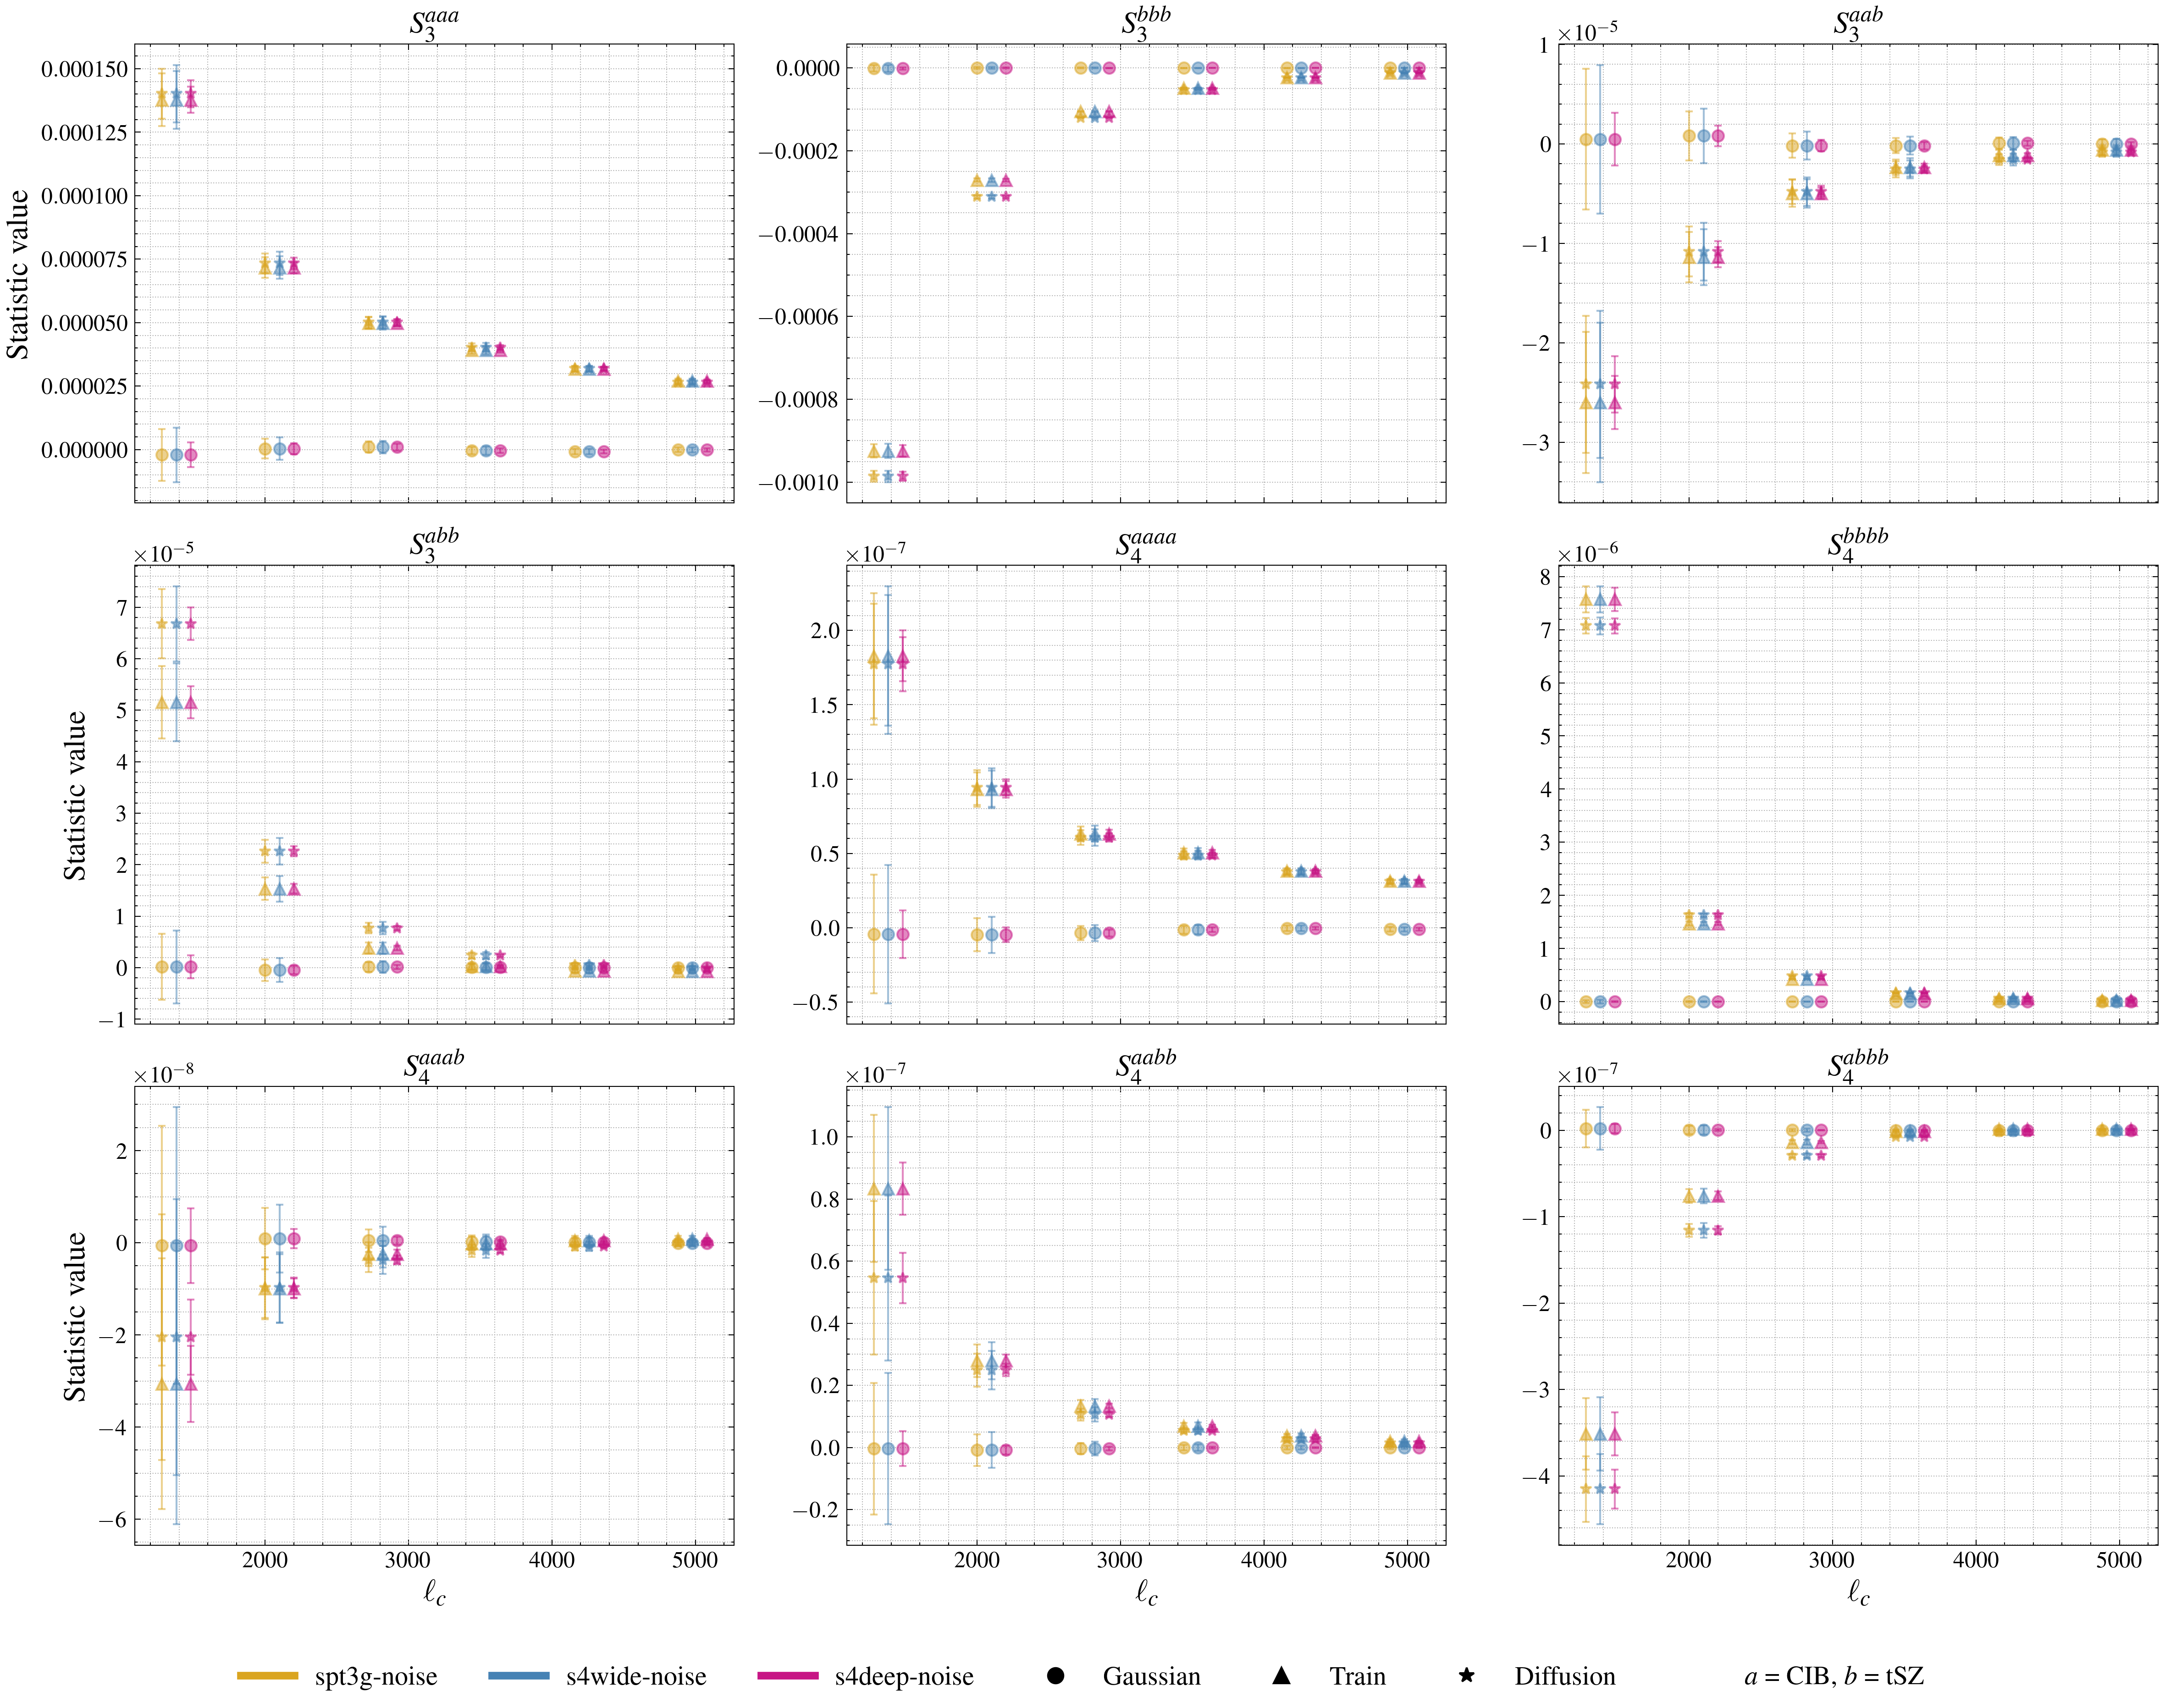

In [234]:
exclude_n = 1
fsval = 16
offset_step = 100

labels = [
    r"$S_3^{aaa}$", r"$S_3^{bbb}$", r"$S_3^{aab}$", r"$S_3^{abb}$",
    r"$S_4^{aaaa}$", r"$S_4^{bbbb}$", r"$S_4^{aaab}$", r"$S_4^{aabb}$", r"$S_4^{abbb}$"
]

colors = {
    "gaussian": "#D55E00",
    "train": "#009E73",
    "diffusion": "#0072B2"
}

noise_colors = {
    "spt3g_noise": "goldenrod",
    "s4wide_noise": "steelblue",
    "s4deep_noise": "mediumvioletred"
}

markers = {
    "gaussian": "o",
    "train": "^",
    "diffusion": "*"
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True)
axes = axes.flatten()

rows, cols = 3, 3
for idx, label in enumerate(labels):
    ax = axes[idx]
    moment_key = f"moment_{3+idx:02d}"

    for noise_i, noise_level in enumerate(noise_levels):
        offset = (noise_i - len(noise_levels) // 2) * offset_step  # center the offsets

        for key in means_clean.keys():
            mean_data = np.array(means_clean[key][moment_key])
            noisy_data = np.array(errors_noisy_all[noise_level][key][moment_key])

            mean_vals = np.mean(mean_data, axis=0)
            std_errs = np.std(noisy_data, axis=0) / np.sqrt(noisy_data.shape[0])

            # Shifted x-axis
            shifted_x = bandpass_centers[exclude_n:] + offset
            label_str = fr"${key.capitalize()}$ ({noise_level.replace('_', '-')})" if idx == 0 else None

            ax.errorbar(shifted_x, mean_vals[exclude_n:], yerr=std_errs[exclude_n:],
                fmt=markers[key], capsize=2, color=noise_colors[noise_level], alpha=0.5,
                label=label_str)

    ax.set_title(label, fontsize=fsval)
    ax.grid(True, which='both', ls=':', lw=0.5)
    row = idx // cols
    col = idx % cols
    if row == rows - 1:
        ax.set_xlabel(r'$\ell_c$', fontsize=fsval)
    if col == 0:
        ax.set_ylabel(r'Statistic value', fontsize=fsval)


noise_legend_handles = [
    Line2D([0], [0], color=color, lw=4, label=noise.replace('_', '-'))
    for noise, color in noise_colors.items()
]

model_legend_handles = [
    Line2D([0], [0], color='black', marker=markers[model], linestyle='None',
           markersize=8, label=model.capitalize())
    for model in markers
]

noise_legend_handles = [
    Line2D([0], [0], color=color, lw=4, label=noise.replace('_', '-'))
    for noise, color in noise_colors.items()
]

# Model marker handles
model_legend_handles = [
    Line2D([0], [0], color='black', marker=markers[model], linestyle='None',
           markersize=8, label=model.capitalize())
    for model in markers
]
# Label for a = CIB, b = tSZ
ab_legend_handle = Line2D([], [], color='none', label=r"$a$ = CIB, $b$ = tSZ")

combined_handles = noise_legend_handles + model_legend_handles + [ab_legend_handle]


fig.legend(handles=combined_handles,
           fontsize=14,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.05),
           ncol=len(combined_handles),
           frameon=False)


plt.tight_layout()
plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_joint_cib_tsz.pdf", dpi=200, bbox_inches="tight")
plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_joint_cib_tsz.png", dpi=200, bbox_inches="tight")
plt.show()

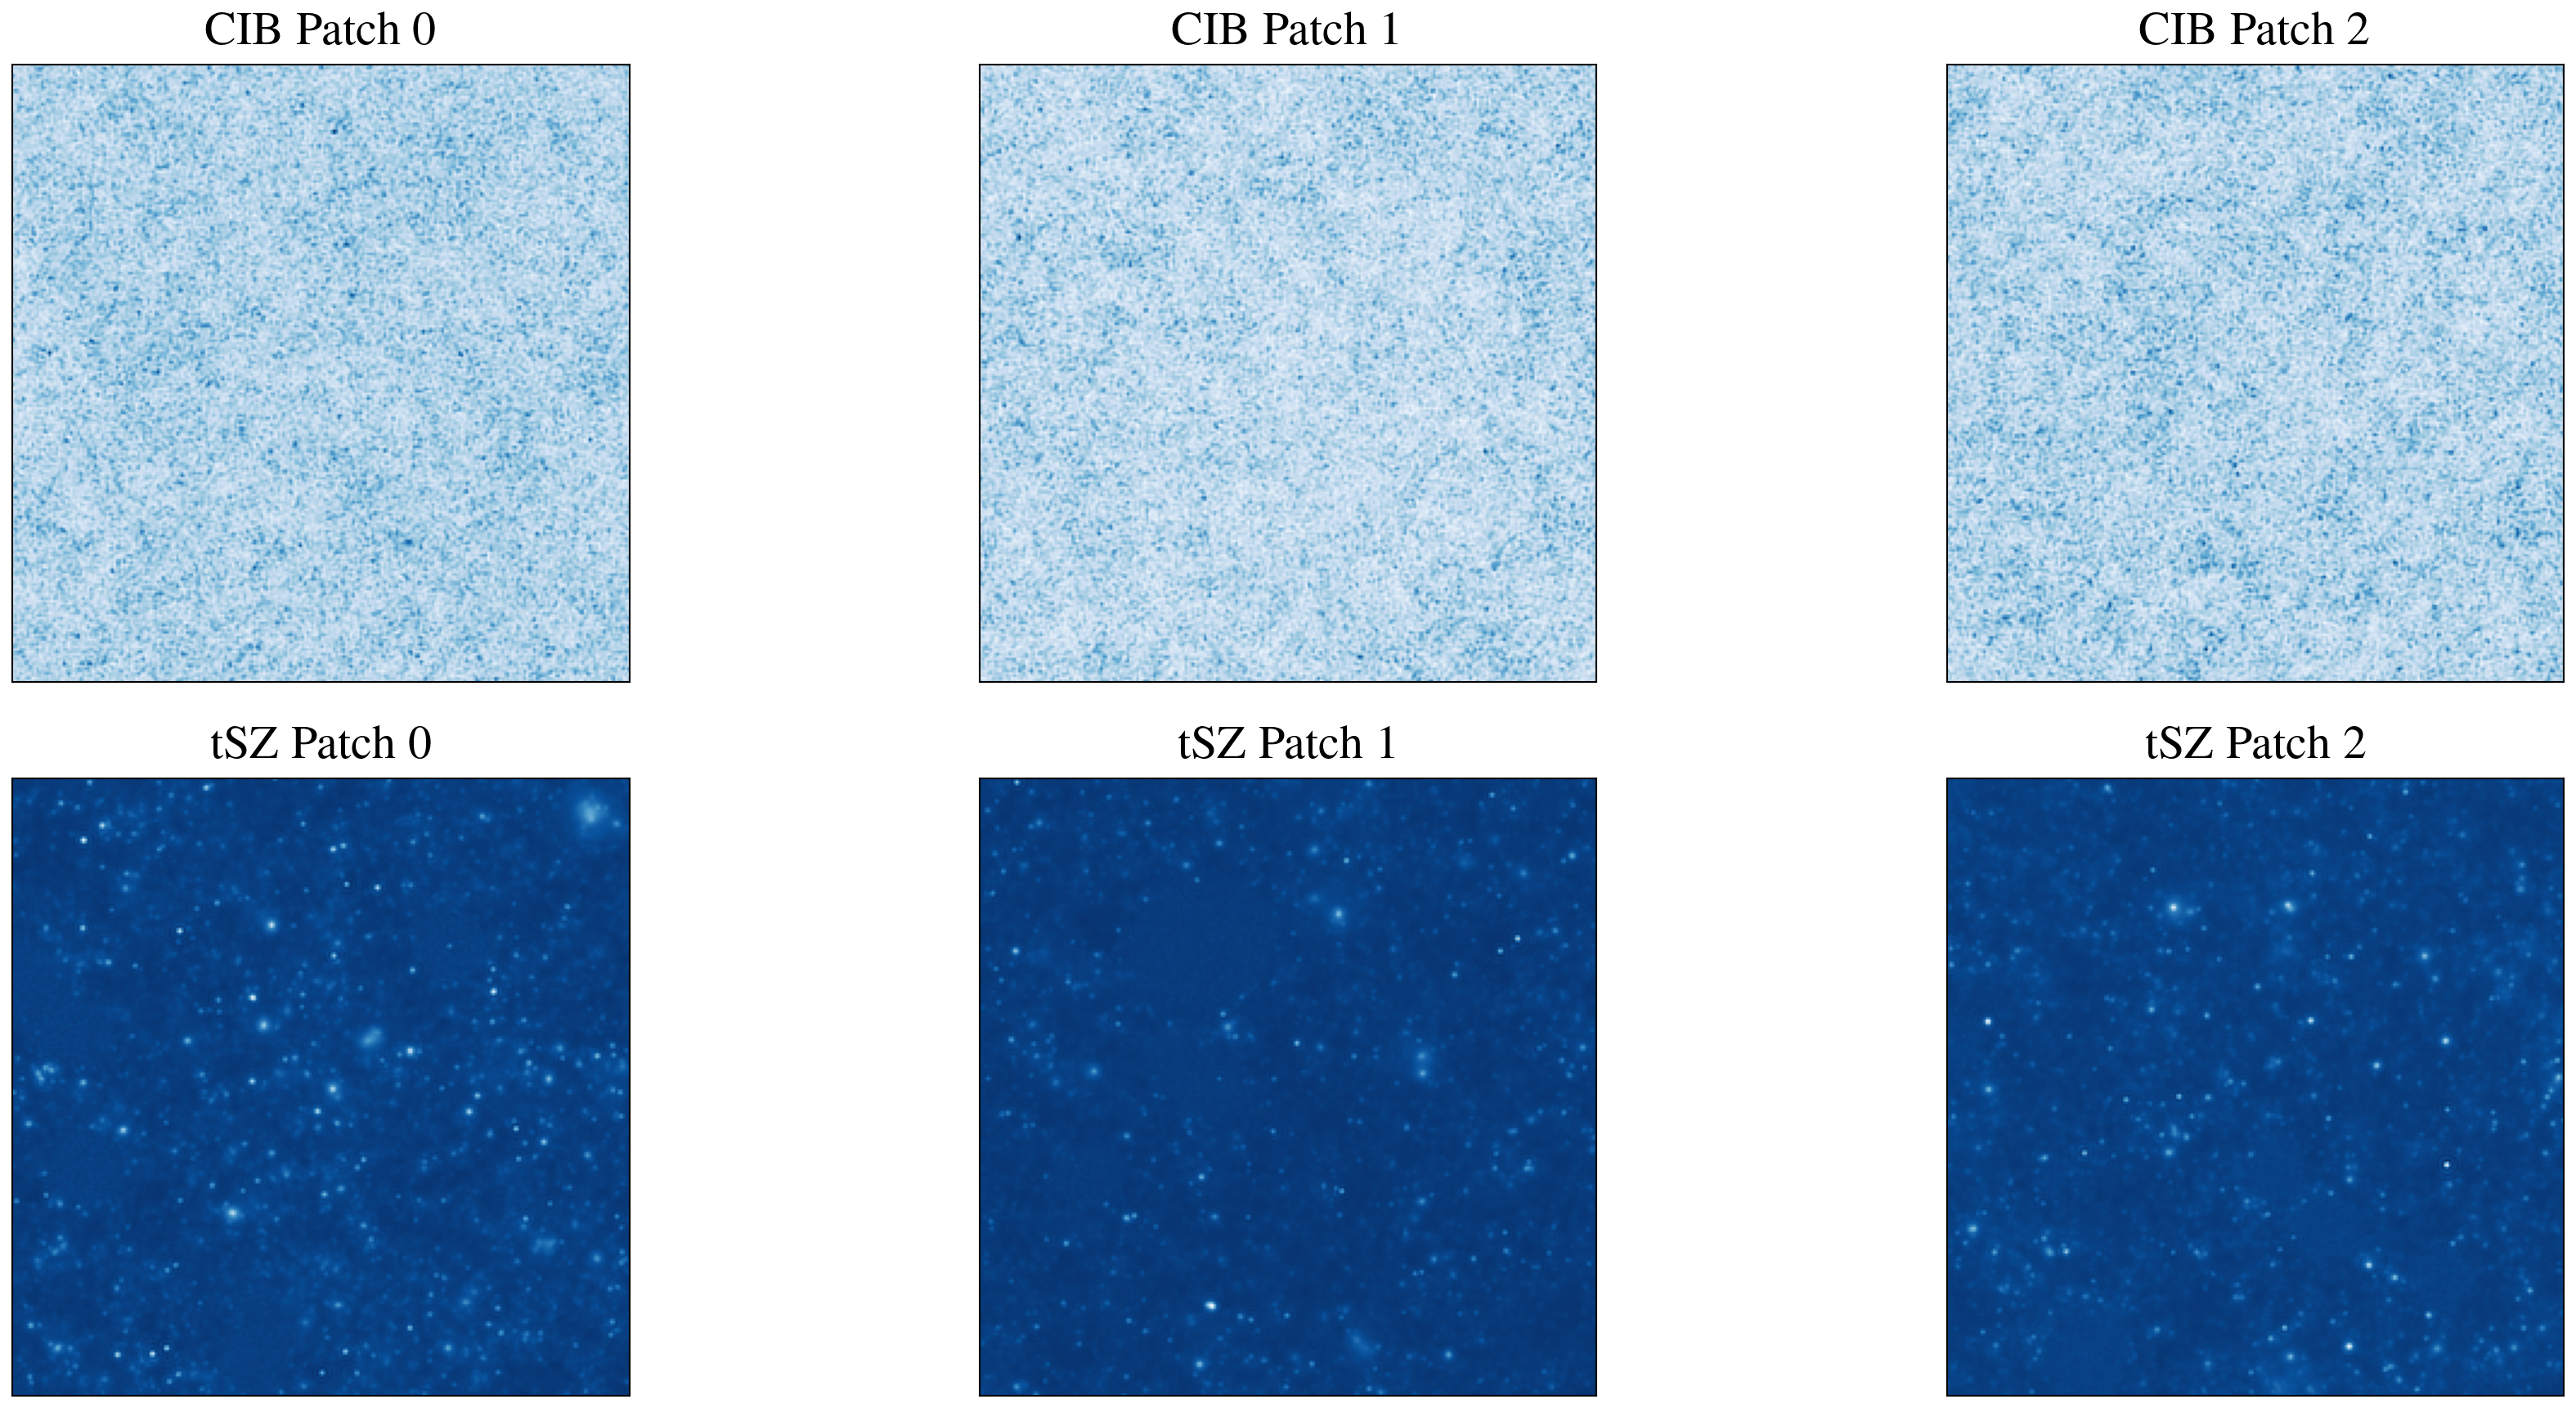

In [38]:
#dataset = 'agora' 
dataset = 'diffusion'

fig, axs = plt.subplots(2, 3, figsize=(12, 6))
vmin_cib, vmax_cib = None, None
vmin_tsz, vmax_tsz = None, None
cmap_cib = 'Blues'
cmap_tsz = 'Blues'

for i in range(3):
    index = i
    if dataset == 'agora':
        img_cib = training_images[index, :, :, 0]
        img_tsz = training_images[index, :, :, 1]
    elif dataset == 'diffusion':
        img_cib = all_samples[index, :, :, 0]
        img_tsz = all_samples[index, :, :, 1]
    else:
        raise ValueError("Dataset must be 'agora' or 'diffusion'")
    _,apodized_mask = get_peak_masks(img_tsz, mask_threshold_sigma_units = mask_threshold_sigma_units_tsz, mask_radius_pixel_units = mask_radius_pixel_units, taper_radius_fac = apod_taper_radius_fac)
    img_cib = np.copy(img_cib)#*apodized_mask
    img_tsz = np.copy(img_tsz)#*apodized_mask
    
    im_cib = axs[0, i].imshow(img_cib, cmap=cmap_cib, vmin=vmin_cib, vmax=vmax_cib)
    axs[0, i].set_title(f"CIB Patch {index}", fontsize=14)

    im_tsz = axs[1, i].imshow(img_tsz, cmap=cmap_tsz, vmin=vmin_tsz, vmax=vmax_tsz)
    axs[1, i].set_title(f"tSZ Patch {index}", fontsize=14)

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.subplots_adjust(wspace=0.05)
plt.show()

In [114]:
def compute_cls(dataset, i, flatskymapparams):
    cib_map = dataset[i, :, :, 0] - np.mean(dataset[i, :, :, 0])
    tsz_map = dataset[i, :, :, 1] - np.mean(dataset[i, :, :, 1])

    _, apodised_tsz_mask = get_peak_masks(tsz_map, mask_threshold_sigma_units = mask_threshold_sigma_units_tsz, mask_radius_pixel_units = mask_radius_pixel_units, taper_radius_fac = apod_taper_radius_fac)

    cib_map_masked = np.copy(cib_map)*apodised_tsz_mask
    tsz_map_masked = np.copy(tsz_map)*apodised_tsz_mask
    
    el, cl_cib_cib = map2cl(flatskymapparams, cib_map_masked,)
    _, cl_tsz_tsz = map2cl(flatskymapparams, tsz_map_masked)
    _, cl_cib_tsz = map2cl(flatskymapparams, cib_map_masked, tsz_map_masked)
    return el, cl_cib_cib, cl_tsz_tsz, cl_cib_tsz

In [115]:
cls_train = {'CIBxCIB': [], 'tSZxtSZ': [], 'CIBxtSZ': []}
cls_diffusion = {'CIBxCIB': [], 'tSZxtSZ': [], 'CIBxtSZ': []}
for i in range(200):
    # Training
    el, cl_cib_cib, cl_tsz_tsz, cl_cib_tsz = compute_cls(training_images, i, flatskymapparams)
    cls_train['CIBxCIB'].append(cl_cib_cib)
    cls_train['tSZxtSZ'].append(cl_tsz_tsz)
    cls_train['CIBxtSZ'].append(cl_cib_tsz)

    # Diffusion model
    el, cl_cib_cib, cl_tsz_tsz, cl_cib_tsz = compute_cls(all_samples, i, flatskymapparams)
    cls_diffusion['CIBxCIB'].append(cl_cib_cib)
    cls_diffusion['tSZxtSZ'].append(cl_tsz_tsz)
    cls_diffusion['CIBxtSZ'].append(cl_cib_tsz)

In [116]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

/tmp/ipykernel_102208/2555039425.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=10, loc='upper right')
/tmp/ipykernel_102208/2555039425.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


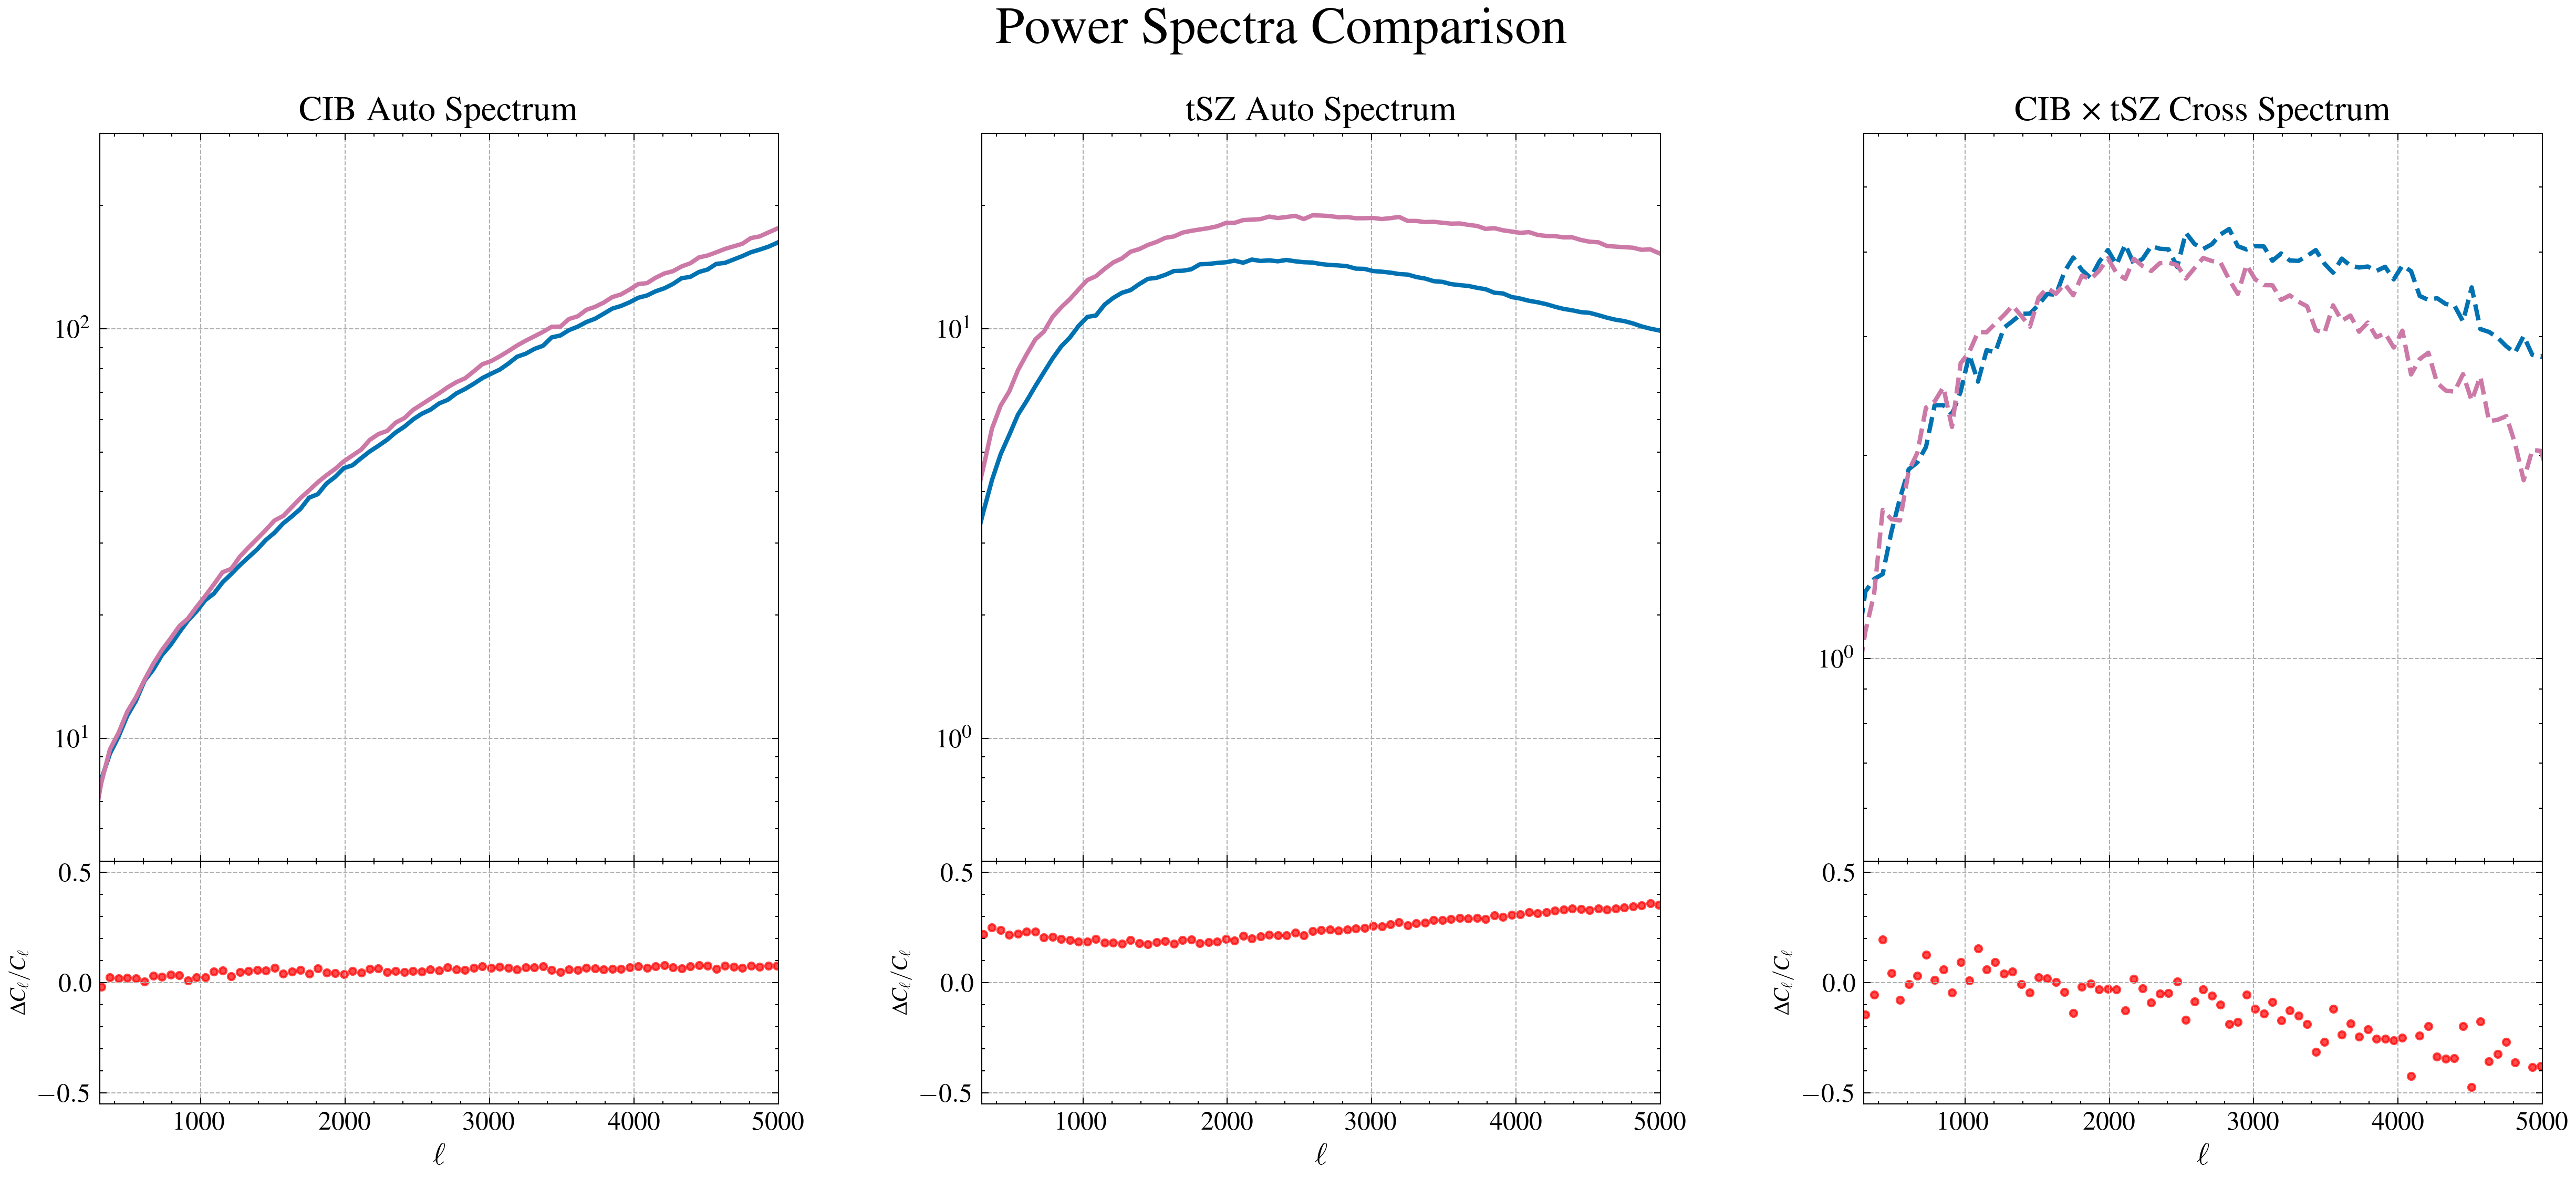

In [117]:
def plot_all_cls(el, cls_train, cls_diffusion, titles, ylim_mains, ylim_bias, save_path=None):
    fig = plt.figure(figsize=(20, 8))
    outer = GridSpec(1, 3, wspace=0.3)  # 3 columns for 3 plots

    for idx, key in enumerate(['CIBxCIB', 'tSZxtSZ', 'CIBxtSZ']):
        inner = GridSpecFromSubplotSpec(2, 1, height_ratios=[3, 1], hspace=0, subplot_spec=outer[idx])
        
        ax1 = fig.add_subplot(inner[0])
        ax2 = fig.add_subplot(inner[1], sharex=ax1)

        # Diffusion model
        low_dm = np.percentile(cls_diffusion[key], 2.5, axis=0)
        high_dm = np.percentile(cls_diffusion[key], 97.5, axis=0)
        #ax1.fill_between(el, low_dm, high_dm, color='#0072B2', alpha=0.2, label="Diffusion model samples")
        ax1.plot(el, el*(el+1)*np.mean(cls_diffusion[key], axis=0), color='#0072B2', lw=2)
        ax1.plot(el, -1*el*(el+1)*np.mean(cls_diffusion[key], axis=0), color='#0072B2', lw=2,linestyle='--')

        # Training samples
        low_train = np.percentile(cls_train[key], 2.5, axis=0)
        high_train = np.percentile(cls_train[key], 97.5, axis=0)
        #ax1.fill_between(el, low_train, high_train, color='#CC79A7', alpha=0.2, label="Test samples")
        ax1.plot(el, el*(el+1)*np.mean(cls_train[key], axis=0), color='#CC79A7', lw=2)
        ax1.plot(el, -1*el*(el+1)*np.mean(cls_train[key], axis=0), color='#CC79A7', lw=2,linestyle='--')
                 
        ax1.set_yscale('log')
        ax1.set_xlim(300, 5000)
        ax1.set_ylim(ylim_mains[idx])
        ax1.set_title(titles[idx], fontsize=16)
        ax1.legend(fontsize=10, loc='upper right')
        ax1.tick_params(axis='both', labelsize=12)
        plt.setp(ax1.get_xticklabels(), visible=False)

        # Bias plot
        bias = (np.mean(cls_train[key], axis=0) - np.mean(cls_diffusion[key], axis=0)) / np.mean(cls_train[key], axis=0)
        ax2.scatter(el, bias, marker='o', color='red', alpha=0.7, s=10)
        ax2.set_xlabel(r"$\ell$", fontsize=14)
        ax2.set_ylabel(r"$\Delta C_\ell / C_\ell$", fontsize=10)
        ax2.set_ylim(ylim_bias)
        ax2.tick_params(axis='both', labelsize=12)

    fig.suptitle("Power Spectra Comparison", fontsize=24)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Call
plot_all_cls(
    el,
    cls_train,
    cls_diffusion,
    titles=["CIB Auto Spectrum", "tSZ Auto Spectrum", "CIB × tSZ Cross Spectrum"],
    #ylim_mains=[(5e-6, 2e-4), (2e-7, 2e-4), (1e-8, 1e-4)],
    ylim_mains=[(5,300), (0.5,30), (0.5,6)],
    ylim_bias=(-0.55, 0.55),
    save_path="figures/power_spectra_w_masking.pdf"  
)

In [335]:
rho_agora = np.mean(cls_train['CIBxtSZ']/np.sqrt(np.array(cls_train['CIBxCIB'])*cls_train['tSZxtSZ']),axis=0)

In [336]:
rho = np.mean(cls_diffusion['CIBxtSZ']/np.sqrt(np.array(cls_diffusion['CIBxCIB'])*cls_diffusion['tSZxtSZ']),axis=0)

(300.0, 6000.0)

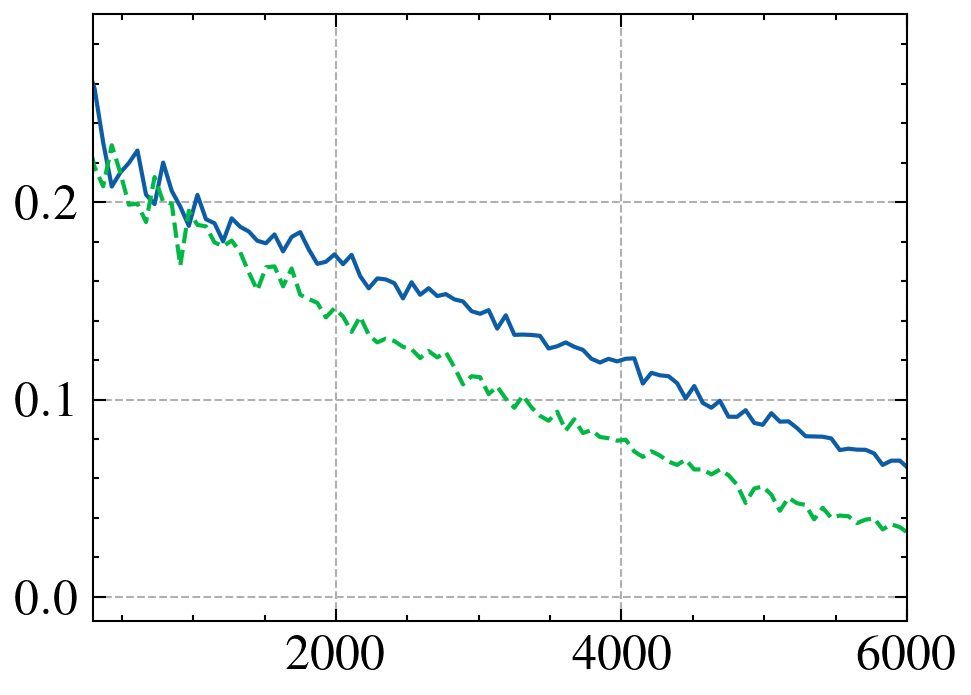

In [337]:
plt.plot(el,abs(rho))
plt.plot(el,abs(rho_agora),'--')
plt.xlim(300,6000)